In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
def h(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = r2 - r1
    return pref * (r1[0] + r2[0]) * d[1] - lam * np.sqrt(np.sum(d**2))

In [3]:
def g12(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = pt2 - pt1 + 1.5
    d %= 1
    d -= 0.5
    lambd = lam * d / np.sqrt(np.sum(d**2))
    g1x = pref * d[1] - lambd[0]
    g1y = -pref * (r1[0] + r2[0]) - lambd[1]
    g2x = pref * d[1] - lambd[0]
    g2y = pref * (r1[0] + r2[0]) - lambd[1]
    return np.array([g1x, g1y]), np.array([g2x, g2y])

In [4]:
def getNumericalOverlapForce(m):
    eps = 1e-6
    m.updateNeighbors(0)
    OA0 = m.functional(h)[0]
    dA = np.zeros(m.getNumVertices() * 2)
    pos0 = m.getPositions()
    for i in range(m.getNumVertices()):
        for j in range(2):
            positions = pos0.copy()
            positions[2 * i + j] += eps
            m.setPositions(positions)
            m.updateNeighbors(0)
            dA[2 * i + j] = (m.functional(h)[0] - OA0) / eps
    m.setPositions(pos0.copy())
    return -dA

<AxesSubplot: >

<Figure size 640x480 with 0 Axes>

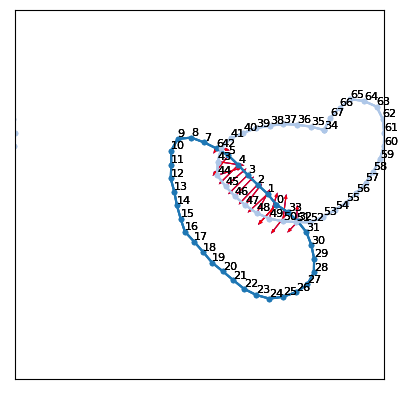

In [5]:
numPolygons = 2
n = 34
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 0
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12)
numericalForce = getNumericalOverlapForce(m)
# Now you have dA, can you draw arrows on the vertices?
ax = m.draw(numbering = True, forces = numericalForce, arrowColor = 'r')
m.draw(ax = ax, numbering = True, forces = force, arrowColor = 'b')
m.draw(ax = ax, numbering = True, forces = numericalForce, arrowColor = 'r')

In [6]:
# Let's start by just computing forces for functionInterior
# We somehow need to place g1_xy and g2_xy (so 2 functions)
# into the functional

In [7]:
#numericalForce - force

In [8]:
# Now we got that working!
# Let's move on to figuring out the edge intersections. Let's get a new
# notebook for that. Go to df.ipynb for those function (which appear below).

In [9]:
# Here's our df function so we can try that again. We need to do products with g1 and g2

<AxesSubplot: >

<Figure size 640x480 with 0 Axes>

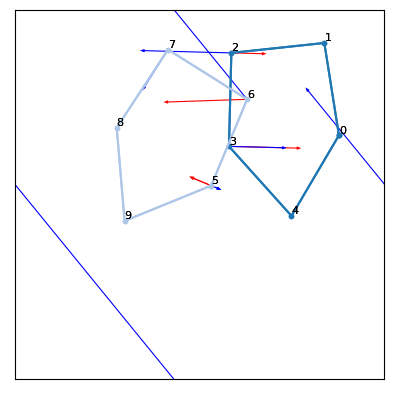

In [10]:
numPolygons = 2
n = 5
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 2
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12, lam = 1, pref = 1)
numericalForce = getNumericalOverlapForce(m)
# Now you have dA, can you draw arrows on the vertices?
ax = m.draw(numbering = True, forces = numericalForce, arrowColor = 'r')
m.draw(ax = ax, numbering = True, forces = force, arrowColor = 'b')
#m.draw(ax = ax, numbering = True, forces = numericalForce, arrowColor = 'g')
#ax.plot([0.58327569],[0.78543454], 'o')
#ax.plot([0.5795493], [0.63973589], 'o')

In [11]:
np.max(np.abs(numericalForce - force))

1.039934372872271

<AxesSubplot: >

<Figure size 640x480 with 0 Axes>

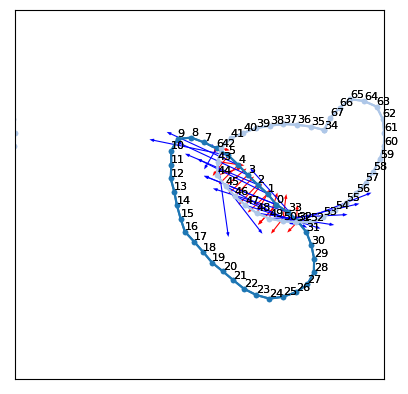

In [12]:
numPolygons = 2
n = 34
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 0
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12, lam = 0.1, pref = 1)
numericalForce = getNumericalOverlapForce(m)
# Now you have dA, can you draw arrows on the vertices?
ax = m.draw(numbering = True, forces = numericalForce, arrowColor = 'r')
m.draw(ax = ax, numbering = True, forces = force, arrowColor = 'b')

In [13]:
np.max(np.abs(force - numericalForce))

0.20041899770383848

In [14]:
# We can get forces now! Let's test this rigorously:

/home/rdennis/Documents/Code/pyCudaPolygon/pyCudaPolygon/polygonMixins/polygonUtils.py:68: RuntimeWarning: invalid value encountered in sqrt
  return np.sum(l) / np.sqrt(A)


<AxesSubplot: >

<Figure size 640x480 with 0 Axes>

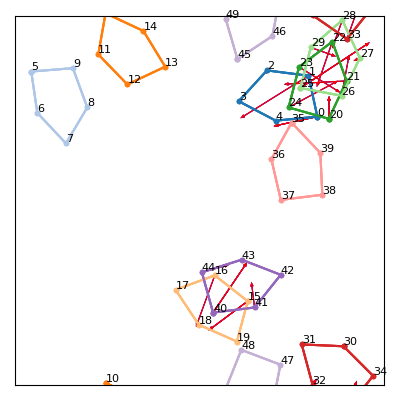

In [15]:
numPolygons = 10
n = 5
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 3
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
#m.setPositions((m.getPositions() + 0.5) % 1)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12)
numericalForce = getNumericalOverlapForce(m)
# Now you have dA, can you draw arrows on the vertices?
ax = m.draw(numbering = True, forces = numericalForce, arrowColor = 'r')
m.draw(ax = ax, forces = force, arrowColor = 'b')
m.draw(ax = ax, forces = numericalForce, arrowColor = 'r')

In [16]:
np.max(np.abs(force - numericalForce))

7.739319295985148e-07

In [17]:
np.argwhere(np.abs(force - numericalForce) > 1e-6).T / 2

array([], shape=(1, 0), dtype=float64)

In [18]:
# Yeah, this looks right I think:

<AxesSubplot: >

<Figure size 640x480 with 0 Axes>

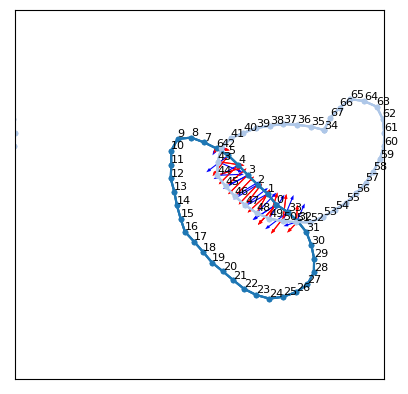

In [19]:
lam = 0.01
pref = 1
numPolygons = 2
n = 34
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 0
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.2)
#m.setPositions((m.getPositions() + 0.5) % 1)
plt.clf()
# Works fine
m.setMaxEdgeLength(0.5)
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h, g12 = g12, lam = lam, pref = pref)
numericalForce = getNumericalOverlapForce(m)
# Now you have dA, can you draw arrows on the vertices?
ax = m.draw(numbering = True, forces = numericalForce, arrowColor = 'r')
m.draw(ax = ax, forces = force, arrowColor = 'b')
m.draw(ax = ax, forces = numericalForce, arrowColor = 'r')

In [20]:
m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, maxSteps = 3000)
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0)
overlapArea, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900


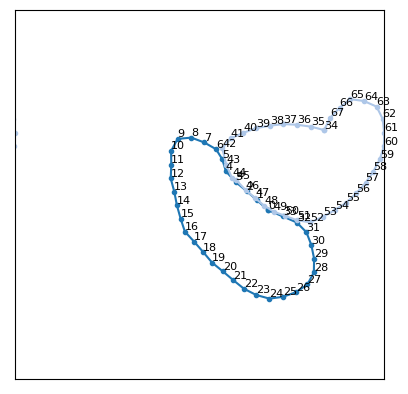

In [21]:
ax = m.draw(numbering = True, forces = force, arrowColor = 'r')

In [22]:
np.max(np.abs(force))

0.0